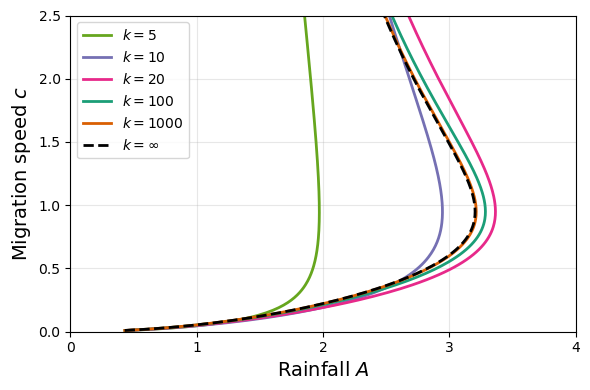

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy.optimize import root_scalar

#Computes the Hopf Bifurcation of Gamma 
def Gamma_hopf(c, kappa):
    rad = c**4 + 4.0 + 4.0*c**2/kappa
    return (kappa + 1.0)**2 / (2.0 * c * kappa**2) * (c**2 + 2.0 - np.sqrt(rad))

#Computes omega^2 at the Hopf bifurcation point
#omega^2 > 0 is required for a complex conjugate pair to cross the imaginary axis
def omega2_at_hopf(Gamma, c, kappa):
    return (kappa - 1.0)/kappa - Gamma * c * kappa**2 / (kappa + 1.0)**2

#Defines the Hopf Conditions with the rescalings 
def A_on_hopf_for_c(c_pde, B, nu, k):
    c_star = c_pde / np.sqrt(B)

    def F(A):
        kappa = B * k / A
        Gamma = A**2 / (B**2.5 * nu)
        return Gamma - Gamma_hopf(c_star, kappa)
    
    #Solving for A
    A_grid = np.linspace(0.05, 8.0, 2000)
    vals = np.array([F(A) for A in A_grid])
    idx = np.where(np.sign(vals[:-1]) * np.sign(vals[1:]) < 0)[0]
    if len(idx) == 0:
        return np.nan

    a, b = A_grid[idx[0]], A_grid[idx[0] + 1]
    sol = root_scalar(F, bracket=[a, b], method="brentq")
    if not sol.converged:
        return np.nan
     
    A = sol.root
    
    #checking if omega^2>0
    kappa = B * k / A
    Gamma = A**2 / (B**2.5 * nu)
    w2 = omega2_at_hopf(Gamma, c_star, kappa)
    if w2 <= 0:
        return np.nan

    return A

#the k-->infinity case 
def A_explicit_curve(c, B, nu):
    chat = B**(-1/2) * c
    inside = (2.0 + chat**2 - np.sqrt(4.0 + chat**4)) / (2.0 * chat)
    inside = np.where(inside > 0, inside, np.nan)
    return np.sqrt(nu) * B**(5/4) * np.sqrt(inside)

#Plotting for finite k
def plot_hopf_curve(B=0.45, nu=182.5, k=10, c_min=0.01, c_max=2.5, n=250, color=None):
    cs = np.linspace(c_min, c_max, n)
    As = np.array([A_on_hopf_for_c(c, B, nu, k) for c in cs])
    plt.plot(As, cs, label=rf"$k={k}$", color=color, linewidth=2)

def plot_explicit_curve(B=0.45, nu=182.5, c_min=0.01, c_max=2.5, n=250, color=None):
    cs = np.linspace(c_min, c_max, n)
    As = A_explicit_curve(cs, B, nu)
    plt.plot(As, cs, "--", linewidth=2, label=r"$k=\infty$", color=color)

plt.figure(figsize=(6, 4))

plot_hopf_curve(k=5, color="#66a61e")
plot_hopf_curve(k=10, color="#7570b3")
plot_hopf_curve(k=20, color="#e7298a")
plot_hopf_curve(k=100, color="#1b9e77")
plot_hopf_curve(k=1000, color="#d95f02")
plot_explicit_curve(color="black")

ax = plt.gca()
ax.set_xlabel(r"Rainfall $A$", fontsize=14)
ax.set_ylabel(r"Migration speed $c$", fontsize=14)
ax.set_xlim(0, 4)
ax.set_ylim(0, 2.5)

ax.xaxis.set_major_locator(MultipleLocator(1))
ax.yaxis.set_major_locator(MultipleLocator(0.5))

ax.grid(True, which="major", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig("Hopf Bifurcation.pdf", format="pdf")
plt.show()

In [2]:
#Finding A_max for the numerical simulation section
import numpy as np
from scipy.optimize import root_scalar

def Gamma_max(khat):
    return ((khat + 1.0)**2 / khat**2) * (np.sqrt(2.0) - np.sqrt(1.0 + 1.0/khat))

def F(A, B, nu, k):
    khat = B * k / A
    return A**2 / (nu * B**(5/2)) - Gamma_max(khat)

B = 0.45
nu = 182.5
k = 10

sol = root_scalar(F, args=(B, nu, k), bracket=[0.1, 10.0], method="brentq")

ks = [3, 10, 20, 100, 1000]

for k in ks:
    sol = root_scalar(F, args=(B, nu, k), bracket=[0.1, 10.0], method="brentq")
    if sol.converged:
        print(f"k={k:4}, A*={sol.root:.6f}")
    else:
        print(f"k={k:4}, no convergence")

k=   3, A*=1.283723
k=  10, A*=2.946076
k=  20, A*=3.365705
k= 100, A*=3.286252
k=1000, A*=3.213460


In [3]:
import numpy as np
from scipy.optimize import root_scalar

B, nu = 0.45, 182.5

def A_max(k):
    """Solve A^2/(nu*B^(5/2)) = Gamma_max(Bk/A) for A, where
    Gamma_max(khat) = ((khat+1)^2/khat^2) * (sqrt(2) - sqrt(1 + 1/khat))
    is the maximum of Gamma_H over all migration speeds (attained at chat=sqrt(2))."""
    def F(A):
        khat = B * k / A
        Gamma = ((khat + 1)**2 / khat**2) * (np.sqrt(2) - np.sqrt(1 + 1/khat))
        return A**2 / (nu * B**2.5) - Gamma
    try:
        sol = root_scalar(F, bracket=[0.1, 10.0], method="brentq")
        return sol.root if sol.converged else np.nan
    except:
        return np.nan

# k=inf closed form: Amax(inf) = sqrt(sqrt(2)-1) * sqrt(nu) * B^(5/4)
A_inf = np.sqrt(np.sqrt(2) - 1) * np.sqrt(nu) * B**1.25

ks = np.linspace(1, 200, 5000)
Amax_vals = np.array([A_max(k) for k in ks])

# Key quantities
k_max = ks[np.nanargmax(Amax_vals)]
A_at_kmax = np.nanmax(Amax_vals)

# Zero crossing: where A_max(k) = A_inf
diff = Amax_vals - A_inf
cross = np.where(np.diff(np.sign(diff)))[0]
k_cross = ks[cross[0]] - diff[cross[0]] * (ks[1] - ks[0]) / (diff[cross[0]+1] - diff[cross[0]])

print(f"A_max(inf)             = {A_inf:.4f}")
print(f"k where A_max = A_inf  = {k_cross:.4f}")
print(f"k_max                  = {k_max:.4f}")
print(f"A_max(k_max)           = {A_at_kmax:.4f}")
print(f"A_max(k_max) - A_inf   = {A_at_kmax - A_inf:.4f}")

A_max(inf)             = 3.2045
k where A_max = A_inf  = 13.3871
k_max                  = 26.9150
A_max(k_max)           = 3.3895
A_max(k_max) - A_inf   = 0.1850


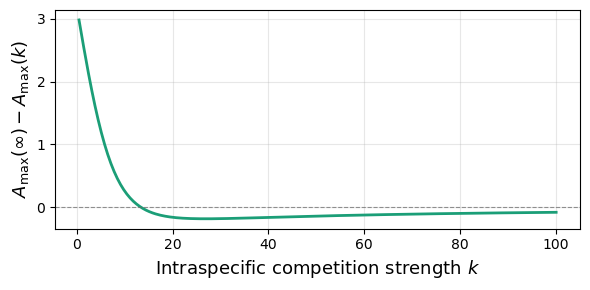

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
from matplotlib.ticker import MultipleLocator

#Parameters
B = 0.45
nu = 182.5

def Gamma_max(khat):
    return ((khat + 1.0)**2 / khat**2) * (np.sqrt(2.0) - np.sqrt(1.0 + 1.0 / khat))

def A_max_finite_k(k, B, nu):
    def F(A):
        khat = B * k / A
        return A**2 / (nu * B**(5/2)) - Gamma_max(khat)

    A_grid = np.linspace(0.05, 8.0, 4000)
    vals = np.array([F(A) for A in A_grid])
    idx = np.where(np.sign(vals[:-1]) * np.sign(vals[1:]) < 0)[0]

    if len(idx) == 0:
        return np.nan

    a, b = A_grid[idx[0]], A_grid[idx[0] + 1]
    sol = root_scalar(F, bracket=[a, b], method="brentq")
    return sol.root if sol.converged else np.nan

def A_max_infty(B, nu):
    return np.sqrt(np.sqrt(2.0) - 1.0) * np.sqrt(nu) * B**(5/4)

ks = np.linspace(0.5, 100, 300)

Ainf = A_max_infty(B, nu)

Amax_vals = []
valid_ks = []

for k in ks:
    Amax = A_max_finite_k(k, B, nu)
    if not np.isnan(Amax):
        valid_ks.append(k)
        Amax_vals.append(Amax)

valid_ks = np.array(valid_ks)
Amax_vals = np.array(Amax_vals)

#Absolute difference from k = infinity
abs_diff = -Amax_vals + Ainf

plt.figure(figsize=(6, 3))
plt.plot(valid_ks, abs_diff, linewidth=2, color="#1b9e77")
plt.axhline(y=0, color='dimgray', linestyle='--', linewidth=0.8, alpha=0.7)
plt.xlabel(r"Intraspecific competition strength $k$", fontsize=13)
plt.ylabel(r"$A_{\max}(\infty) - A_{\max}(k)$", fontsize=13)
ax = plt.gca()
ax.yaxis.set_major_locator(MultipleLocator(1))
ax.xaxis.set_major_locator(MultipleLocator(20))
ax.grid(True, which="major", alpha=0.3)

plt.tight_layout()
plt.savefig("Absolute_difference_Amax.pdf", format="pdf")
plt.show()

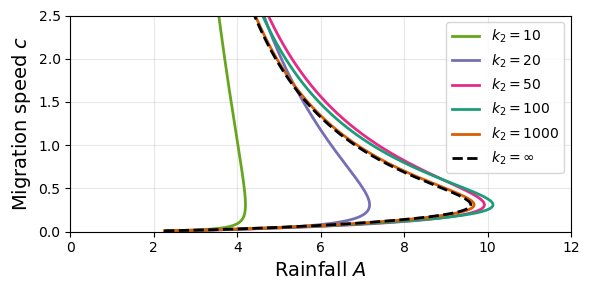

In [5]:
#APPENDIX B
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from scipy.optimize import root_scalar

def Gamma_hopf(cstar, kappa):
    rad = cstar**4 + 4.0 + 4.0*cstar**2/kappa
    return ((kappa + 1.0)**2 / (2.0 * cstar * kappa**2)) * (
        cstar**2 + 2.0 - np.sqrt(rad))

def omega2_at_hopf(Gamma, cstar, kappa):
    return (kappa - 1.0)/kappa - Gamma * cstar * kappa**2 / (kappa + 1.0)**2


def A_on_hopf_for_c(c_pde, B2, nu, k2, Ffac, H, D,
                    A_min=0.05, A_max=12.0, ngrid=4000):

    c_star = c_pde / np.sqrt(B2)

    if c_star <= 0:
        return np.nan

    def objective(A):
        kappa = B2 * k2 / (A * Ffac)
        Gamma = (np.sqrt(D) * A**2 * Ffac**2 * H) / (nu * B2**(2.5))

        return Gamma - Gamma_hopf(c_star, kappa)

    A_grid = np.linspace(A_min, A_max, ngrid)
    vals = np.array([objective(A) for A in A_grid])

    good = np.isfinite(vals)
    idx = np.where(good[:-1] & good[1:] & (vals[:-1] * vals[1:] < 0))[0]

    if len(idx) == 0:
        return np.nan

    a, b = A_grid[idx[0]], A_grid[idx[0] + 1]
    sol = root_scalar(objective, bracket=[a, b], method="brentq")

    if not sol.converged:
        return np.nan

    A = sol.root
    kappa = B2 * k2 / (A * Ffac)
    Gamma = (np.sqrt(D) * A**2 * Ffac**2 * H) / (nu * B2**(2.5))
    w2 = omega2_at_hopf(Gamma, c_star, kappa)

    if w2 <= 0:
        return np.nan

    return A

def A_explicit_curve_new(c, B2, nu, Ffac, H, D):
    c_hat = c / np.sqrt(B2)

    inside = (2.0 + c_hat**2 - np.sqrt(4.0 + c_hat**4)) / (2.0 * c_hat)
    inside = np.where(inside > 0, inside, np.nan)
    return (
        np.sqrt(nu) * B2**(1.25) * np.sqrt(inside)
        / (Ffac * np.sqrt(H) * D**0.25)
    )

def plot_hopf_curve(B2=0.45, nu=182.5, k2=10, Ffac=1.0, H=1.0, D=1.0,
                    c_min=0.01, c_max=2.5, n=250, color=None):
    cs = np.linspace(c_min, c_max, n)
    As = np.array([A_on_hopf_for_c(c, B2, nu, k2, Ffac, H, D) for c in cs])
    plt.plot(As, cs, linewidth=2, color=color, label=rf"$k_2={k2}$")

def plot_explicit_curve(B2=0.45, nu=182.5, Ffac=1.0, H=1.0, D=1.0,
                        c_min=0.01, c_max=2.5, n=250, color="black"):
    cs = np.linspace(c_min, c_max, n)
    As = A_explicit_curve_new(cs, B2, nu, Ffac, H, D)
    plt.plot(As, cs, "--", linewidth=2, color=color, label=r"$k_2=\infty$")

plt.figure(figsize=(6, 3))

B2 = 0.0486
nu = 182.5
Ffac = 0.109
H = 0.109
D = 0.109

plot_hopf_curve(B2=B2, nu=nu, k2=10,    Ffac=Ffac, H=H, D=D, color="#66a61e")
plot_hopf_curve(B2=B2, nu=nu, k2=20,   Ffac=Ffac, H=H, D=D, color="#7570b3")
plot_hopf_curve(B2=B2, nu=nu, k2=50,   Ffac=Ffac, H=H, D=D, color="#e7298a")
plot_hopf_curve(B2=B2, nu=nu, k2=100,  Ffac=Ffac, H=H, D=D, color="#1b9e77")
plot_hopf_curve(B2=B2, nu=nu, k2=1000, Ffac=Ffac, H=H, D=D, color="#d95f02")

plot_explicit_curve(B2=B2, nu=nu, Ffac=Ffac, H=H, D=D, color="black")

ax = plt.gca()
ax.set_xlabel(r"Rainfall $A$", fontsize=14)
ax.set_ylabel(r"Migration speed $c$", fontsize=14)
ax.set_xlim(0, 12)
ax.set_ylim(0, 2.5)

ax.xaxis.set_major_locator(MultipleLocator(2))
ax.yaxis.set_major_locator(MultipleLocator(0.5))
ax.grid(True, which="major", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig("Hopf_Bifurcation_new.pdf", format="pdf")
plt.show()